# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 4 - Regression/Analysis

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#!pip install h3
import h3
import matplotlib.patches as mpatches
import seaborn as sns
#!pip install scipy
from scipy.stats import skew
import statsmodels.api as sm

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results
df_dir = os.path.join(current_path, "dataframes")

In [3]:
# Load any dataframe from that folder
admin_city = gpd.read_file(os.path.join(df_dir, "admin_city_vienna.geojson"))
urban_green_spaces =gpd.read_file(os.path.join(df_dir, "urban_green_spaces.geojson"))
urban_blue_spaces = gpd.read_file(os.path.join(df_dir, "urban_blue_spaces.geojson"))
ugbs_socioecon_census = gpd.read_file(os.path.join(df_dir, "ugbs_socioecon_census.geojson"))
socioecon_districts = gpd.read_file(os.path.join(df_dir, "socioecon_districts.geojson"))
housingprices_district = gpd.read_file(os.path.join(df_dir, "housingprices_district.geojson"))
social_housing = pd.read_csv(os.path.join(df_dir, "social_housing.csv"))
social_housing_gdf = gpd.read_file(os.path.join(df_dir, "social_housing.geojson"))
aptfeatures_social_census = pd.read_csv(os.path.join(df_dir, "aptfeatures_social_census.csv"))
apt_features_final_census = pd.read_csv(os.path.join(df_dir, "apt_features_final_census.csv"))
airbnb_entireunits_gdf = gpd.read_file(os.path.join(df_dir, "airbnb_entireunits.geojson"))

Skipping field ways: unsupported OGR type: 1
Skipping field amenities: unsupported OGR type: 5


### Remembering all (geo)dataframes

In [4]:
urban_green_spaces.head(3)

,id,OBJECTID,T_TEXT,T_LANG,F_TYP,circumference,area,geometry
0,OEFFGRUENFLOGD.3203,3203,Kellerberg Liesing,Kellerberg Liesing,L,3639.130056,252272.443774,"POLYGON ((16.3126 48.12082, 16.31255 48.12015,..."
1,OEFFGRUENFLOGD.2935,2935,Kellerberg Liesing,Kellerberg Liesing,L,3550.454846,139775.046918,"POLYGON ((16.31275 48.12182, 16.31053 48.12171..."
2,OEFFGRUENFLOGD.3327,3327,Auf der Schanz,Auf der Schanz,L,748.705565,10111.920974,"POLYGON ((16.29882 48.12579, 16.29882 48.12579..."


In [5]:
urban_blue_spaces.head(3)

,element_type,osmid,source,created_by,odbl,river:waterway_distance,waterway,seamark:type,name,maxwidth,...,year_of_construction,toilets:wheelchair,memorial,fence_type,abandoned,lit,attraction,name:sh,species:wikidata,geometry
0,way,184034195,None,None,None,None,river,None,Donau,None,...,None,None,None,None,None,None,None,None,None,POINT (16.57614 48.13556)
1,way,827580757,None,None,None,None,river,None,Donau,None,...,None,None,None,None,None,None,None,None,None,"MULTILINESTRING ((16.56378 48.13854, 16.5663 4..."
2,relation,1773323,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((16.57697 48.14432, 16.57696 48.1442,..."


In [6]:
print(len(ugbs_socioecon_census))
ugbs_socioecon_census.head(3)

246


,index,ZBEZ,green_area_sum,university_share,avg_income,employment,benefit_share,SSI,quintile,blue_area_sum,census_area_m2,green_ratio,blue_ratio,geometry
0,0,0101,8998.122749,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,377557.211380,377461.6586,0.024,1.000,"POLYGON ((3497.002 341023.556, 3487.789 341009..."
1,1,0102,121895.900833,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,401343.274110,379376.7503,0.321,1.058,"POLYGON ((3642.199 340685.896, 3641.629 340684..."
2,2,0103,114294.691336,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,465496.860383,465496.8591,0.246,1.000,"POLYGON ((2629.739 340221.176, 2600.5 340197.5..."


In [7]:
socioecon_districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,area,circumference,AKT_TIMEST,SE_SDO_ROW,district_avgincome,district_employment,district_univshare,district_benefitshare,district_SSI,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,3.771397e+07,29668.16,2023-07-18,13126.0,0.642256,0.369003,0.549082,0.285477,0.561803,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3.916953e+06,9711.71,2023-07-18,13127.0,-0.591063,-0.260053,0.175842,-0.071401,-0.214924,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,1.608248e+06,5312.54,2023-07-18,13128.0,0.409909,0.407823,1.101009,0.588805,0.743321,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."


In [8]:
housingprices_district.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4132,4043,4423,4462,4821,5593,6159,5327,4799.11,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3369,3315,3827,3860,4111,4729,4460,4215,3812.78,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4553,4755,5405,5833,6043,6332,6336,5929,5551.11,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."


In [9]:
apt_features_final_census.head(3)

,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other
0,90100,90101,2686,94,2592,1271,483,4,928
1,90100,90102,945,31,914,559,33,4,349
2,90100,90103,1294,34,1260,708,74,0,512


In [10]:
social_housing.head(3)

,Hofname,clean_address,Wohnungen,Lokale
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse",4289,25
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße",284,7
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse",5525,41


In [11]:
social_housing_gdf.head(3)

,Hofname,clean_address,Wohnungen,Lokale,addr_key,geometry
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse",4289,25,"1100 wien, jura-soyfer-gasse",POINT (16.39202 48.14767)
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße",284,7,"1210 wien, leopoldauer straße",POINT (16.40495 48.25741)
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse",5525,41,"1210 wien, st.-michael-gasse",POINT (16.43977 48.26674)


In [12]:
aptfeatures_social_census['census_district_code'].dtype

dtype('int64')

In [13]:
aptfeatures_social_census['census_district_code'] = (
    aptfeatures_social_census['census_district_code']
    .apply(lambda x: str(x).zfill(4))
)

In [14]:
aptfeatures_social_census['census_district_code'].dtype

dtype('O')

In [15]:
aptfeatures_social_census.head(3)
print(len(aptfeatures_social_census))

249


### Creation of the one necessary dataframe
* This data frame includes for every census district (250)
    * census district code
  * socioeconomic variables (avg_income, SSI mainly)
  * green ratio
  * blue ratio
  * apartment features (type of ownership, heating type)
  * how many social housing exists in that census district
  * social housing rate

* This dataframe is created by using ugbs_socioecon_census & aptfeatures_social_census

* It's name is 'merged_census'

In [16]:
print(len(ugbs_socioecon_census))
print(len(aptfeatures_social_census))

246
249


In [17]:
boundaries_path = 'data/ZAEHLBEZIRKOGDPolygon.shp'
census_boundaries = gpd.read_file(boundaries_path)
print(len(census_boundaries))

250


In [18]:
merged_census = ugbs_socioecon_census.merge(
    aptfeatures_social_census, 
    left_on='ZBEZ', 
    right_on='census_district_code', 
    how='outer'
)

# Convert back to GeoDataFrame, using the original geometry
merged_census = gpd.GeoDataFrame(merged_census, geometry='geometry')
# Set the correct CRS (copied from ugbs_socioecon_census)
merged_census.set_crs(ugbs_socioecon_census.crs, inplace=True)

print(merged_census.columns.to_list())
print(len(merged_census))
print(type(merged_census))

['index', 'ZBEZ', 'green_area_sum', 'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 'blue_area_sum', 'census_area_m2', 'green_ratio', 'blue_ratio', 'geometry', 'district_code', 'census_district_code', 'total_apartments', 'no_central_heating', 'central_heating', 'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'social_housing_units', 'social_housing_ratio']
249
<class 'geopandas.geodataframe.GeoDataFrame'>


In [19]:
merged_census.drop(['census_district_code'], axis=1, inplace=True)
print(merged_census.columns.to_list())
merged_census.rename(columns={'district_code': 'BEZ'}, inplace=True)
merged_census.head(3)

['index', 'ZBEZ', 'green_area_sum', 'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 'blue_area_sum', 'census_area_m2', 'green_ratio', 'blue_ratio', 'geometry', 'district_code', 'total_apartments', 'no_central_heating', 'central_heating', 'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'social_housing_units', 'social_housing_ratio']


,index,ZBEZ,green_area_sum,university_share,avg_income,employment,benefit_share,SSI,quintile,blue_area_sum,...,BEZ,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,social_housing_units,social_housing_ratio
0,0.0,0101,8998.122749,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,377557.211380,...,90100,2686,94,2592,1271,483,4,928,18.0,0.0067
1,1.0,0102,121895.900833,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,401343.274110,...,90100,945,31,914,559,33,4,349,54.0,0.0571
2,2.0,0103,114294.691336,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,465496.860383,...,90100,1294,34,1260,708,74,0,512,0.0,0.0000


In [20]:
merged_census['centralheating_rate'] = merged_census['central_heating'] / merged_census['total_apartments']
merged_census['private_ownership_rate'] = merged_census['owner_private'] / merged_census['total_apartments']
print(merged_census.columns.to_list())
merged_census.head(3)

['index', 'ZBEZ', 'green_area_sum', 'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 'blue_area_sum', 'census_area_m2', 'green_ratio', 'blue_ratio', 'geometry', 'BEZ', 'total_apartments', 'no_central_heating', 'central_heating', 'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'social_housing_units', 'social_housing_ratio', 'centralheating_rate', 'private_ownership_rate']


,index,ZBEZ,green_area_sum,university_share,avg_income,employment,benefit_share,SSI,quintile,blue_area_sum,...,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,social_housing_units,social_housing_ratio,centralheating_rate,private_ownership_rate
0,0.0,0101,8998.122749,1.604954,1.741399,1.125923,1.123008,1.653992,5.0,377557.211380,...,94,2592,1271,483,4,928,18.0,0.0067,0.965004,0.473194
1,1.0,0102,121895.900833,1.653812,2.565233,1.237000,1.139440,2.000434,5.0,401343.274110,...,31,914,559,33,4,349,54.0,0.0571,0.967196,0.591534
2,2.0,0103,114294.691336,1.706598,3.805033,1.641029,1.232519,2.570582,5.0,465496.860383,...,34,1260,708,74,0,512,0.0,0.0000,0.973725,0.547141


In [21]:
print(type(merged_census))
merged_census.to_file("dataframes/merged_census.geojson", driver="GeoJSON")

<class 'geopandas.geodataframe.GeoDataFrame'>


### Correlation check
* average income per district and apartment prices per sq meter per district
* if they are correlated highly, I can use average income per census district as a proxy for apartment prices per census district per sq meter
* I will use the following 2 dataframes
    * socioecon_district
    * housingprices_district

In [22]:
print(socioecon_districts.columns.to_list())
print(housingprices_district.columns.to_list())

['NAMEK', 'BEZNR', 'BEZ_RZ', 'NAMEK_NUM', 'NAMEK_RZ', 'NAMEG', 'LABEL', 'BEZ', 'DISTRICT_C', 'STATAUSTRI', 'STATAUSTR0', 'area', 'circumference', 'AKT_TIMEST', 'SE_SDO_ROW', 'district_avgincome', 'district_employment', 'district_univshare', 'district_benefitshare', 'district_SSI', 'geometry']
['NAMEK', 'BEZNR', 'BEZ_RZ', 'NAMEK_NUM', 'NAMEK_RZ', 'NAMEG', 'LABEL', 'BEZ', 'DISTRICT_C', 'STATAUSTRI', 'STATAUSTR0', 'area', 'circumference', 'AKT_TIMEST', 'SE_SDO_ROW', 'district_clean', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', 'avg_price_years', 'geometry']


In [23]:
# Correlation matrix
avginc_price_corr = pd.DataFrame({
    'BEZ': socioecon_districts['BEZ'],
    'avg_income': socioecon_districts['district_avgincome'],
    'employment':socioecon_districts['district_employment'],
    'univ_share':socioecon_districts['district_univshare'],
    'benefit_share':socioecon_districts['district_benefitshare'],
    'district_SSI':socioecon_districts['district_SSI'],
    'avg_price': housingprices_district['avg_price_years']
})

In [24]:
print("Min:", avginc_price_corr["avg_income"].min())
print("Max:", avginc_price_corr["avg_income"].max())
print("Mean:", avginc_price_corr["avg_income"].mean())
print("Median:", avginc_price_corr["avg_income"].median())

Min: -0.5910631376117098
Max: 1.3904667246978366
Mean: 0.1718385417552902
Median: 0.2007852089440684


In [25]:
min_inc_row = avginc_price_corr.loc[avginc_price_corr["avg_income"].idxmin()]
max_inc_row = avginc_price_corr.loc[avginc_price_corr["avg_income"].idxmax()]

print("\nDistrict with MIN Average Income:")
print(min_inc_row[["BEZ", "avg_income", "district_SSI", "avg_price"]])

print("\nDistrict with MAX Average Income:")
print(max_inc_row[["BEZ", "avg_income", "district_SSI", "avg_price"]])

## District 1 (i.e. Innere Stadt is an outlier)
## exclude Innere Stadt while looking for correlation


District with MIN Average Income:
BEZ                   15
avg_income     -0.591063
district_SSI   -0.214924
avg_price        3812.78
Name: 1, dtype: object

District with MAX Average Income:
BEZ                   01
avg_income      1.390467
district_SSI    1.456749
avg_price       10787.33
Name: 5, dtype: object


In [26]:
# Compute correlation all 23 district
income_price_corr = avginc_price_corr.corr().loc['avg_income', 'avg_price']
ssi_price_corr = avginc_price_corr.corr().loc['district_SSI', 'avg_price']
print("Correlation (avg_income vs avg_price):", income_price_corr.round(3))
print("Correlation (district_SSI vs avg_price):", ssi_price_corr.round(3))

with open("output/income_price_corr_summary.txt", "w") as f:
    f.write(f"Correlation (avg_income vs avg_price): {income_price_corr.round(3)}\n")
    f.write(f"Correlation (district_SSI vs avg_price): {ssi_price_corr.round(3)}\n")

Correlation (avg_income vs avg_price): 0.782
Correlation (district_SSI vs avg_price): 0.768


In [27]:
# Correlation of districts (excluding Innere Stadt, i.e. BEZ==01)
filtered_df = avginc_price_corr[avginc_price_corr['BEZ'] != '01']

# Compute correlations
income_price_corr_filtered = filtered_df.corr().loc['avg_income', 'avg_price']
ssi_price_corr_filtered = filtered_df.corr().loc['district_SSI', 'avg_price']

# Print results
print(len(filtered_df))
print("Correlation excluding Innere Stadt (avg_income vs avg_price):", income_price_corr_filtered.round(3))
print("Correlation excluding Innere Stadt (district_SSI vs avg_price):", income_price_corr_filtered.round(3))

with open("output/income_price_corr_excInnereStadt_summary.txt", "w") as f:
    f.write(f"Number of districts (excluding Innere Stadt): {len(filtered_df)}\n")
    f.write(f"Correlation excluding Innere Stadt (avg_income vs avg_price): {income_price_corr_filtered.round(3)}\n")
    f.write(f"Correlation excluding Innere Stadt (district_SSI vs avg_price): {ssi_price_corr_filtered.round(3)}\n")

22
Correlation excluding Innere Stadt (avg_income vs avg_price): 0.834
Correlation excluding Innere Stadt (district_SSI vs avg_price): 0.834


In [28]:
# Step 1: Select only relevant columns
plot_df = avginc_price_corr[['avg_income', 'district_SSI', 'avg_price']].copy()
plot_df_filtered = filtered_df[['avg_income', 'district_SSI', 'avg_price']].copy()

# Step 2: Convert all to numeric (in case something was parsed as object)
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
plot_df_filtered = plot_df_filtered.apply(pd.to_numeric, errors='coerce')

# Step 3: Drop any rows with NaNs
plot_df = plot_df.dropna()
plot_df_filtered = plot_df_filtered.dropna()

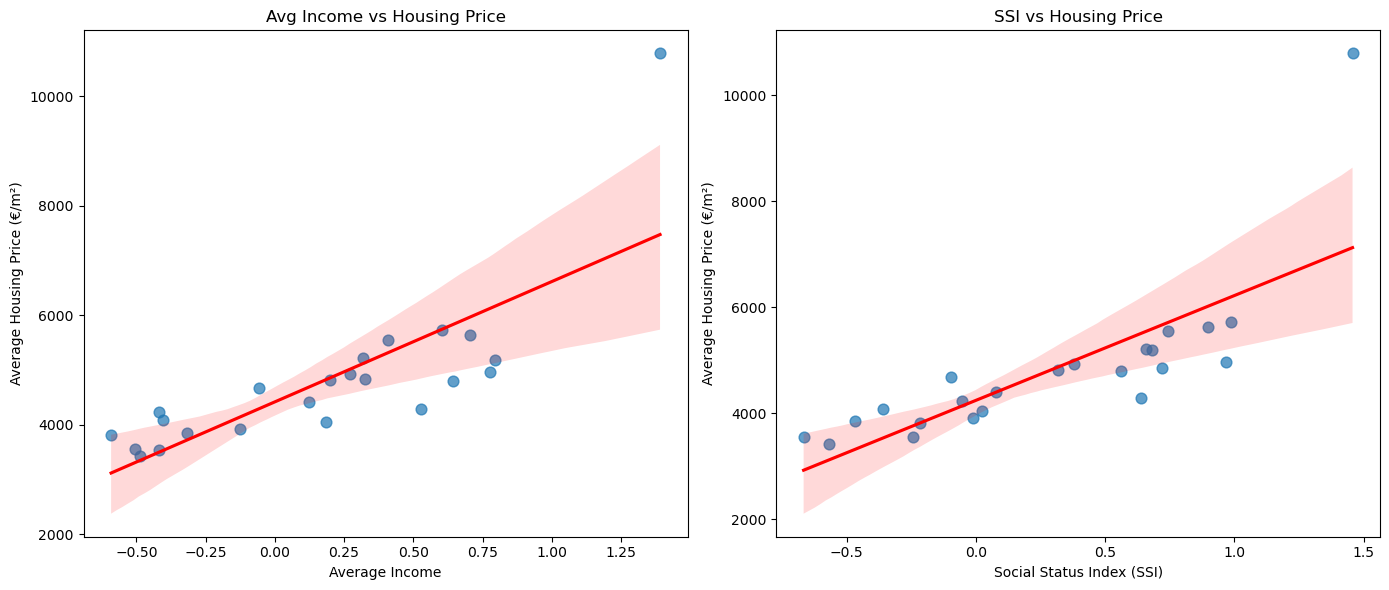

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price
sns.regplot(
    data=plot_df,
    x='avg_income',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# district_SSI vs avg_price
sns.regplot(
    data=plot_df,
    x='district_SSI',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('SSI vs Housing Price')
axes[1].set_xlabel('Social Status Index (SSI)')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/income_price_ssi_corr.png", dpi=300, bbox_inches='tight')
plt.show()

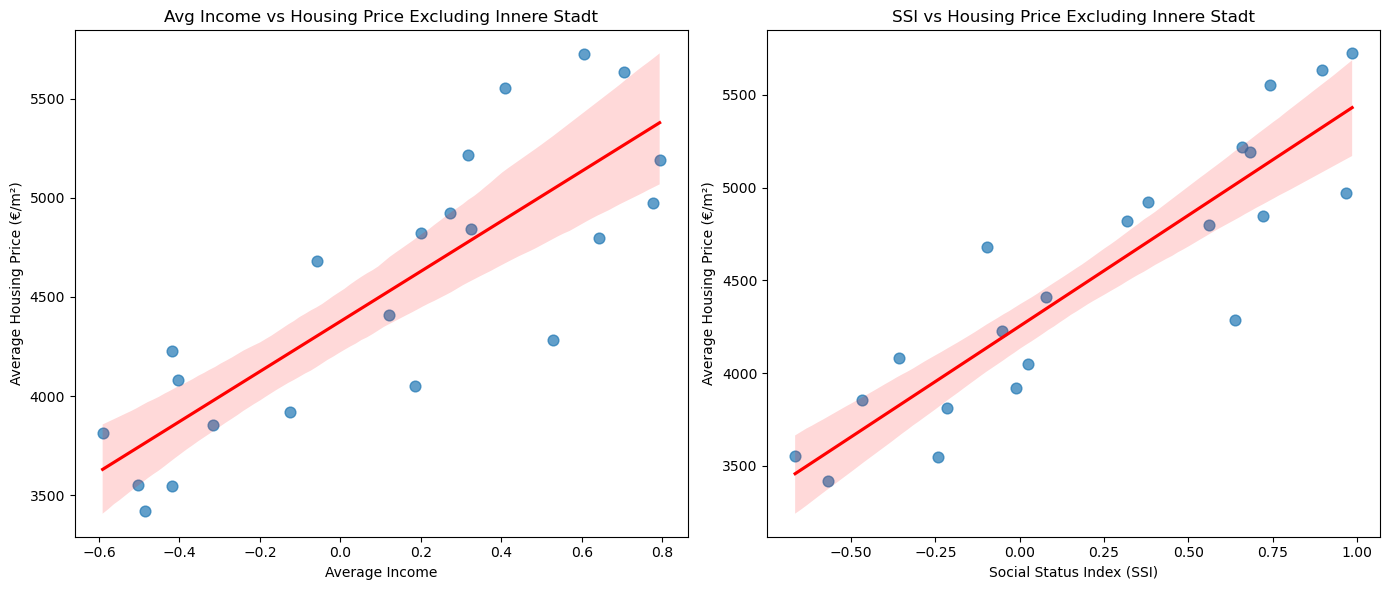

In [30]:
# Correlation excluding Innere Stadt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price
sns.regplot(
    data=plot_df_filtered,
    x='avg_income',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price Excluding Innere Stadt')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# district_SSI vs avg_price
sns.regplot(
    data=plot_df_filtered,
    x='district_SSI',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('SSI vs Housing Price Excluding Innere Stadt')
axes[1].set_xlabel('Social Status Index (SSI)')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/income_price_ssi_corr_filtered.png", dpi=300, bbox_inches='tight')
plt.show()

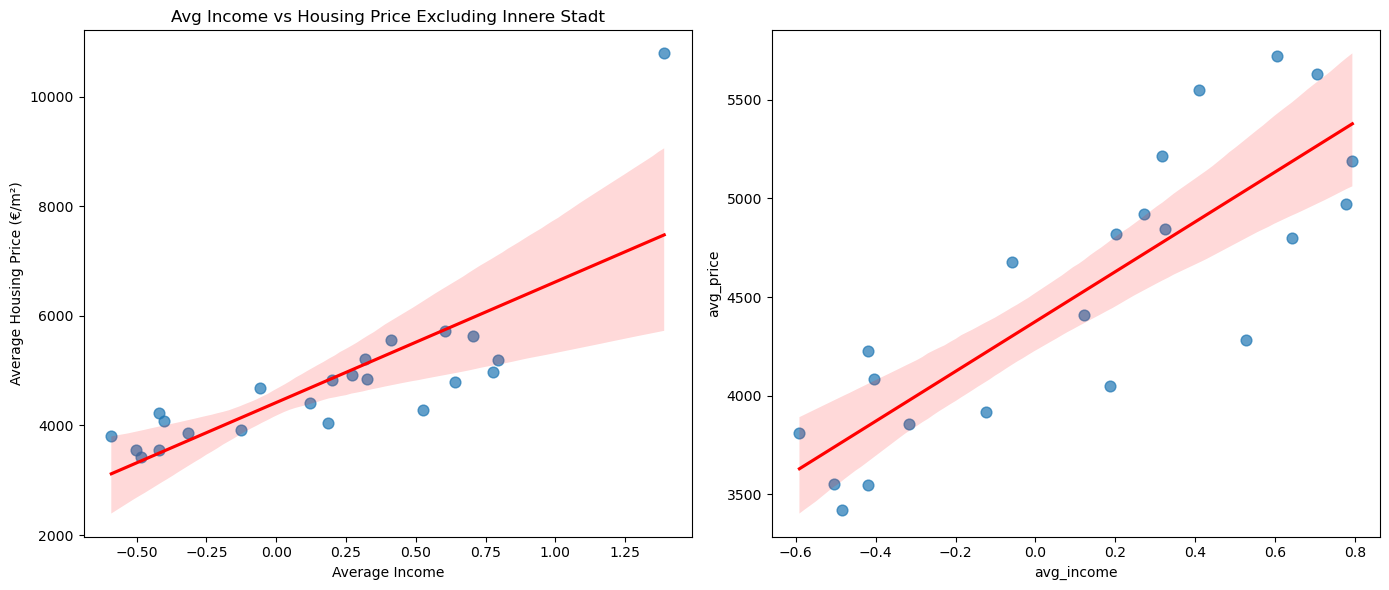

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price (INCLUDING INNERE STADT)
sns.regplot(
    data=plot_df,
    x='avg_income',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# avg_income vs avg_price (EXCLUDING INNERE STADT)
sns.regplot(
    data=plot_df_filtered,
    x='avg_income',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price Excluding Innere Stadt')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.savefig("output/income_price_corr_both.png", dpi=300, bbox_inches='tight')
plt.show()

### OLS

In [32]:
merged_census.columns.to_list()
print(len(merged_census))

249


In [33]:
# check for any NaNs
print(merged_census['green_ratio'].isna().any())
print(merged_census['green_ratio'].isna().sum())
print(merged_census['blue_ratio'].isna().any())
print(merged_census['blue_ratio'].isna().sum())
print(merged_census['social_housing_ratio'].isna().any())
print(merged_census['centralheating_rate'].isna().any())
print(merged_census['private_ownership_rate'].isna().any())

True
3
True
3
False
False
False


In [34]:
# Drop NAs
merged_census_dropped = merged_census[['ZBEZ', 'BEZ',
                                       'university_share', 'avg_income', 'employment', 'benefit_share', 'SSI', 'quintile', 
                                       'green_area_sum', 'blue_area_sum', 'census_area_m2', 'green_ratio', 'blue_ratio', 'geometry', 
                                       'total_apartments', 'no_central_heating', 'central_heating', 'centralheating_rate',
                                       'owner_private', 'owner_public', 'owner_nonprofit', 'owner_other', 'private_ownership_rate',
                                       'social_housing_units', 'social_housing_ratio']].dropna()
print(len(merged_census_dropped))
# so there are 3 rows with NA for green spaces and blue spaces that coincide

246


In [35]:
print(merged_census_dropped['BEZ'].dtype)

int64


In [36]:
merged_census_filtered = merged_census_dropped[merged_census_dropped['BEZ'] != 90100]
print(len(merged_census_filtered)) 
# 7 census districts that are in Innere Stadt are filtered

239


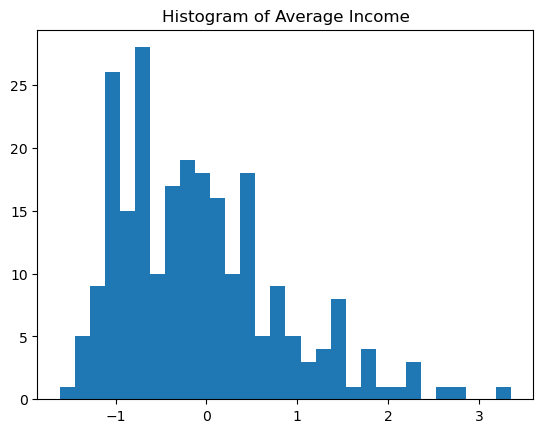

In [37]:
plt.hist(merged_census_filtered['avg_income'], bins=30)
plt.title('Histogram of Average Income')
plt.show()

In [38]:
skewness = skew(merged_census_filtered['avg_income'].dropna())
print("Skewness:", skewness.round(3))

Skewness: 0.973


In [39]:
# MODEL 1 - INCLUDING INNERE STADT, excluding NAs

# Define dependent variable (Y): Average income of each census district
Y = merged_census_dropped['avg_income']  

# Define your independent variables (X)
X = merged_census_dropped[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 
                   'employment', 'university_share', 'private_ownership_rate']]

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
model_246census = sm.OLS(Y, X).fit()
model2_246census = sm.OLS(Y, X).fit(cov_type='HC1')

with open("output/model_246census_summary.txt", "w") as f:
    f.write(model_246census.summary().as_text())

with open("output/model2_246census_summary.txt", "w") as f:
    f.write(model2_246census.summary().as_text())

# Print the summary
print(model_246census.summary())
print(model2_246census.summary())

                            OLS Regression Results                            
Dep. Variable:             avg_income   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     124.7
Date:                Wed, 21 May 2025   Prob (F-statistic):           6.49e-76
Time:                        12:37:39   Log-Likelihood:                -159.08
No. Observations:                 246   AIC:                             334.2
Df Residuals:                     238   BIC:                             362.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -11

In [40]:
# MODEL 2.1 - EXCLUDING INNERE STADT and NAs
# Define dependent variable (Y): Average income of each census district
Y = merged_census_filtered['avg_income']  

# Define your independent variables (X)
X = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 'private_ownership_rate']]

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
model_239census1 = sm.OLS(Y, X).fit(cov_type='HC1')

with open("output/model_239census1_robust_summary.txt", "w") as f:
    f.write(model_239census1.summary().as_text())
    
# Print the summary
print(model_239census1.summary())

latex_table_avgincome_ugbs = model_239census1.summary().as_latex()
with open("output_latex/regression239_avginc_ugbs_robust.tex", "w") as f:
    f.write(latex_table_avgincome_ugbs)

                            OLS Regression Results                            
Dep. Variable:             avg_income   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     47.78
Date:                Wed, 21 May 2025   Prob (F-statistic):           6.92e-34
Time:                        12:37:39   Log-Likelihood:                -207.14
No. Observations:                 239   AIC:                             426.3
Df Residuals:                     233   BIC:                             447.1
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -17

In [41]:
# MODEL 2.2 - EXCLUDING INNERE STADT and NAs
# Define dependent variable (Y): Average income of each census district
Y = merged_census_filtered['avg_income']  

# Define your independent variables (X)
X = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate', 
                   'employment', 'university_share', 'private_ownership_rate']]

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
model_239census2 = sm.OLS(Y, X).fit()
model_239census2_robust = sm.OLS(Y, X).fit(cov_type='HC1')

with open("output/model_239census2_summary.txt", "w") as f:
    f.write(model_239census2.summary().as_text())
    
with open("output/model_239census2_robust_summary.txt", "w") as f:
    f.write(model_239census2_robust.summary().as_text())
    
# Print the summary
print(model_239census2.summary())
print(model_239census2_robust.summary())

latex_table_avgincome_ugbs2 = model_239census2.summary().as_latex()
with open("output_latex/regression_avginc_ugbs2.tex", "w") as f:
    f.write(latex_table_avgincome_ugbs2)

latex_table_avgincome_ugbs2_robust = model_239census2_robust.summary().as_latex()
with open("output_latex/regression_avginc_ugbs2_robust.tex", "w") as f:
    f.write(latex_table_avgincome_ugbs2_robust)

                            OLS Regression Results                            
Dep. Variable:             avg_income   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     146.0
Date:                Wed, 21 May 2025   Prob (F-statistic):           4.04e-81
Time:                        12:37:39   Log-Likelihood:                -109.99
No. Observations:                 239   AIC:                             236.0
Df Residuals:                     231   BIC:                             263.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -9

In [42]:
# MODEL 2.2 - EXCLUDING INNERE STADT and NAs
# Define dependent variable (Y): SSI of each census district
Y = merged_census_filtered['SSI']  

# Define your independent variables (X)
X = merged_census_filtered[['green_ratio', 'blue_ratio', 
                   'social_housing_ratio', 
                   'centralheating_rate']]

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
ssi_ugbs_robust = sm.OLS(Y, X).fit(cov_type='HC1')

with open("output/ssi_ugbs_robust.txt", "w") as f:
    f.write(ssi_ugbs_robust.summary().as_text())
    
# Print the summary
print(ssi_ugbs_robust.summary())

latex_ssi_ugbs_robust = ssi_ugbs_robust.summary().as_latex()
with open("output_latex/regression239_ssi_ugbs_robust.tex", "w") as f:
    f.write(latex_ssi_ugbs_robust)

                            OLS Regression Results                            
Dep. Variable:                    SSI   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     6.390
Date:                Wed, 21 May 2025   Prob (F-statistic):           6.76e-05
Time:                        12:37:39   Log-Likelihood:                -310.56
No. Observations:                 239   AIC:                             631.1
Df Residuals:                     234   BIC:                             648.5
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.9884 

<Axes: xlabel='employment', ylabel='avg_income'>

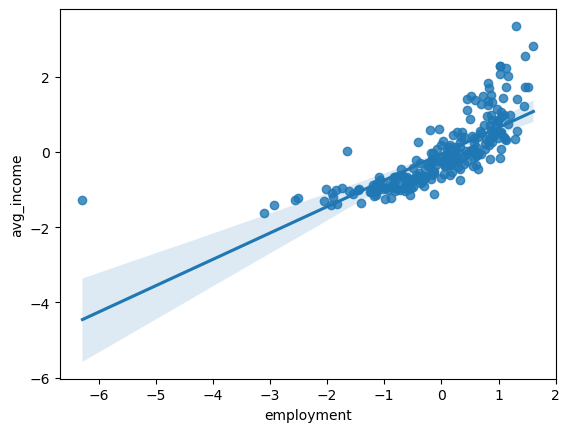

In [43]:
merged_census_filtered[['SSI', 'employment']].corr()

import seaborn as sns
sns.regplot(x='employment', y='avg_income', data=merged_census_filtered)
